# **PRACTICA N° 3: ANALISIS ESTADISTICO DE SEÑALES**

Juan Esteban Hincapie Cardona

Estefania Loaiza Salgado

**Primera parte ECG**

In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.io import loadmat 

**Señal Electrocardiográfica (ECG)**

El electrocardiograma es el registro de la actividad eléctrica del corazón medida a través de electrodos colocados sobre la piel. Esta señal refleja los procesos de despolarización y repolarización de las células cardíacas durante cada latido.

Un ciclo cardíaco típico está compuesto por:

Onda P: despolarización auricular
Complejo QRS: despolarización ventricular
Onda T: repolarización ventricular

Las frecuencias de interés de una señal ECG generalmente se encuentran aproximadamente entre:

0.5 Hz y 40 Hz

Por esta razón, los sistemas de adquisición de ECG suelen utilizar filtros pasa banda que eliminan:

Ruido de baja frecuencia (movimiento del paciente, deriva de línea base)
Ruido de alta frecuencia (interferencia eléctrica o muscular)
Frecuencia de muestreo y duración de la señal

La duración total de una señal digital se calcula como:

𝑇= 𝑁/𝐹𝑠

donde:
N = número total de muestras
𝐹s = frecuencia de muestreo

En este caso:
N = 30720 muestras
Fs = 1024 Hz

Por lo tanto:

**Duración de la señal:**

𝑇 = 30720/1024 = 30s

La señal tiene una duración total de 30 segundos.

El vector de tiempo se crea como:

𝑡 = 0 : 1/𝐹𝑠 : 𝑇

**Parámetros estadísticos**

Para analizar una señal en el dominio del tiempo se utilizan diferentes medidas estadísticas.

* **Promedio**

Representa el valor medio de la señal.

𝜇 = 1/𝑁 ∑𝑥𝑖

* **Valor RMS (Root Mean Square)**

Indica el valor eficaz de la señal.

* **Varianza**

Mide qué tan dispersos están los datos respecto al promedio.

* **Desviación estándar**

Es la raíz cuadrada de la varianza.
	​


In [5]:
#cargar archivo .mat
data = loadmat('signals.mat')
print(data.keys()) #imprime las claves del diccionario cargado

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


1. A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las
señales, cree un vector de tiempo.

In [8]:
Fs = data['Fs'][0][0]   # frecuencia de muestreo

ecg = data['ECG_asRecording'].squeeze()
ecg_filtrada = data['ECG_filtered'].squeeze()

N = len(ecg)            # número de muestras
duracion = N / Fs       # duración de la señal

print("Número de muestras:", N)
print("Frecuencia de muestreo:", Fs)
print("Duración:", duracion, "segundos")

# Vector de tiempo
t = np.arange(0, N) / Fs

Número de muestras: 30720
Frecuencia de muestreo: 1024
Duración: 30.0 segundos


2. Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser
el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.

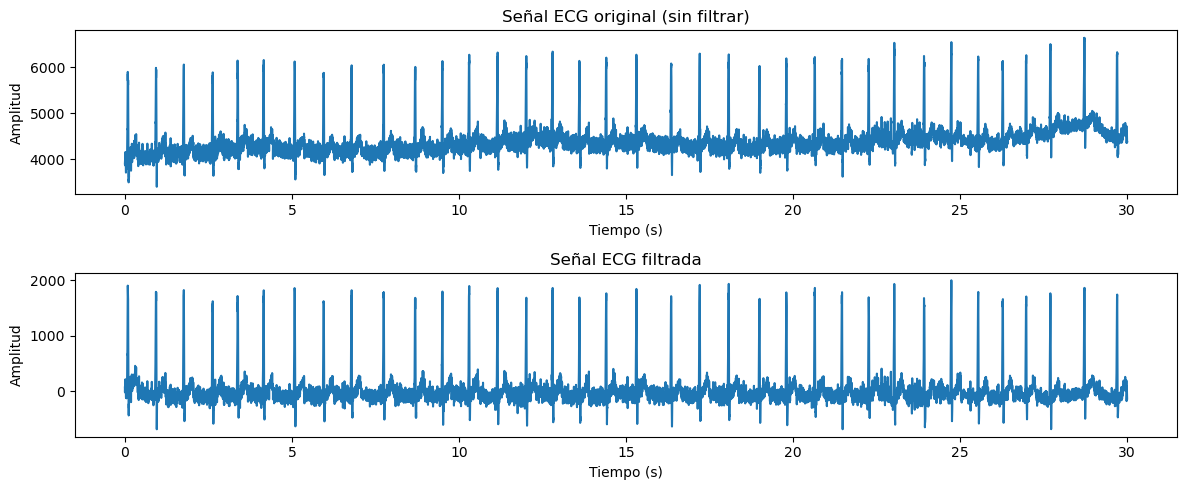

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(2,1,1)
plt.plot(t, ecg)
plt.title("Señal ECG original (sin filtrar)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.subplot(2,1,2)
plt.plot(t, ecg_filtrada)
plt.title("Señal ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()

3. Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el
promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

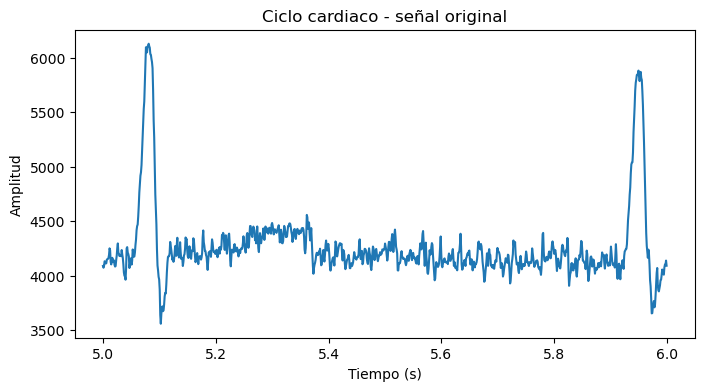

In [11]:
# Seleccionar un ciclo cardiaco (1 segundo aprox)
inicio = int(5 * Fs)       # segundo 5
fin = int(6 * Fs)          # segundo 6

ciclo = ecg[inicio:fin]
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo)
plt.title("Ciclo cardiaco - señal original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

In [12]:
# Promedio
promedio = np.mean(ciclo)

# RMS
rms = np.sqrt(np.mean(ciclo**2))

# Varianza
varianza = np.var(ciclo)

# Desviación estándar
desviacion = np.std(ciclo)

print("Resultados señal original:")
print("Promedio:", promedio)
print("RMS:", rms)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

Resultados señal original:
Promedio: 4264.613161563873
RMS: 4279.476775286304
Varianza: 126996.05243104555
Desviación estándar: 356.3650550082675


4. Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados
obtenidos en el ítem anterior.

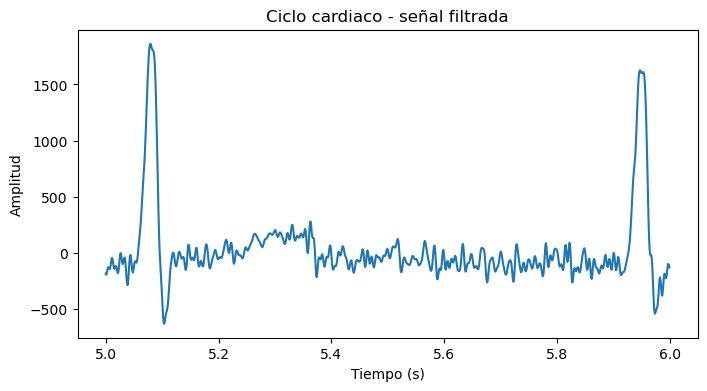

In [13]:
# Seleccionar el mismo ciclo pero de la señal filtrada
ciclo_filtrado = ecg_filtrada[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo_filtrado)
plt.title("Ciclo cardiaco - señal filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

In [14]:
promedio_f = np.mean(ciclo_filtrado)

rms_f = np.sqrt(np.mean(ciclo_filtrado**2))

varianza_f = np.var(ciclo_filtrado)

desviacion_f = np.std(ciclo_filtrado)

print("Resultados señal filtrada:")
print("Promedio:", promedio_f)
print("RMS:", rms_f)
print("Varianza:", varianza_f)
print("Desviación estándar:", desviacion_f)

Resultados señal filtrada:
Promedio: 23.15180801596328
RMS: 353.55848710125093
Varianza: 124467.59758691741
Desviación estándar: 352.7996564438767


------ COMPARACIÓN ------
Promedio original: 4264.613161563873
Promedio filtrado: 23.15180801596328
RMS original: 4279.476775286304
RMS filtrado: 353.55848710125093
Varianza original: 126996.05243104555
Varianza filtrada: 124467.59758691741
Desviación original: 356.3650550082675
Desviación filtrada: 352.7996564438767


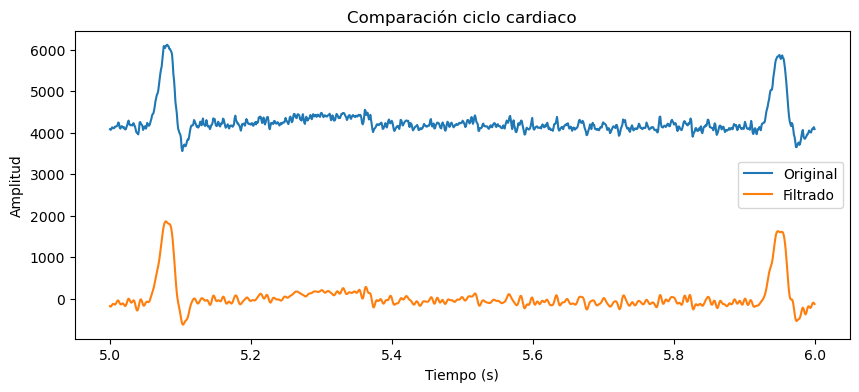

In [15]:
print("------ COMPARACIÓN ------")

print("Promedio original:", promedio)
print("Promedio filtrado:", promedio_f)

print("RMS original:", rms)
print("RMS filtrado:", rms_f)

print("Varianza original:", varianza)
print("Varianza filtrada:", varianza_f)

print("Desviación original:", desviacion)
print("Desviación filtrada:", desviacion_f)

plt.figure(figsize=(10,4))

plt.plot(t_ciclo, ciclo, label="Original")
plt.plot(t_ciclo, ciclo_filtrado, label="Filtrado")

plt.title("Comparación ciclo cardiaco")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()

plt.show()

**Discusión de resultados**

Al graficar la señal ECG original se puede observar la presencia de ruido y pequeñas fluctuaciones que dificultan la identificación clara de los complejos cardíacos. Este ruido puede provenir de diferentes fuentes como interferencia eléctrica, movimiento del paciente o actividad muscular.

Cuando se analiza la señal filtrada se observa una señal mucho más limpia, donde se distinguen con mayor claridad las ondas características del ECG. Esto indica que el filtro aplicado probablemente corresponde a un filtro pasa banda, diseñado para conservar únicamente el rango de frecuencias donde se encuentra la información fisiológica relevante del ECG.

Posteriormente se seleccionó un ciclo cardíaco de aproximadamente un segundo para realizar el análisis estadístico.

* **Señal original (sin filtrar)**

Resultados aproximados del ciclo seleccionado:

Promedio: 4264.61
RMS: 4279.48
Varianza: 126996
Desviación estándar: 356.37

El valor promedio es alto debido a que la señal contiene un nivel DC o desplazamiento de línea base. Además, el ruido presente en la señal incrementa la dispersión de los datos.

* **Señal filtrada**

Resultados aproximados del ciclo:

Promedio: 23.15
RMS: 353.56
Varianza: 124467
Desviación estándar: 352.80

En la señal filtrada se observa que el promedio disminuye considerablemente, lo cual indica que el filtro eliminó gran parte del desplazamiento de línea base. Además, la señal mantiene la estructura fisiológica del ciclo cardíaco pero con menor ruido.

En general, el filtrado mejora la calidad de la señal y permite realizar un análisis más confiable de sus características.

En esta práctica se realizó el análisis de una señal electrocardiográfica (ECG) registrada experimentalmente y almacenada en un archivo .mat. A partir de la frecuencia de muestreo y el número total de muestras se determinó la duración de la señal y se generó su vector de tiempo. Posteriormente se comparó la señal original con la señal filtrada para evaluar el efecto del filtro aplicado. Finalmente, se seleccionó un ciclo cardíaco y se calcularon parámetros estadísticos como el promedio, valor RMS, varianza y desviación estándar, tanto para la señal original como para la señal filtrada.

El resultado más relevante fue observar que el filtrado reduce significativamente el ruido presente en la señal original, permitiendo visualizar con mayor claridad las características del ciclo cardíaco (ondas P, complejo QRS y onda T).

5. Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique
cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?

6. Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine
estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios
para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos
son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t
para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la
estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico
(prueba U de Mann-Whitney).

7. Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal
(Estacionariedad)

**Conclusiones**
* A partir de la frecuencia de muestreo y el número total de muestras se determinó que la señal ECG tiene una duración aproximada de 30 segundos, lo que permitió construir correctamente el vector de tiempo para su análisis.
* El proceso de filtrado mejoró significativamente la calidad de la señal ECG al eliminar componentes de ruido y el desplazamiento de la línea base, facilitando la identificación de las ondas características del ciclo cardíaco.
* Los parámetros estadísticos calculados sobre un ciclo cardíaco permitieron cuantificar las diferencias entre la señal original y la señal filtrada, evidenciando que el filtrado produce una señal más estable y adecuada para el análisis biomédico.